# AgriRisk Rwanda: Machine Learning Models

AgriRisk Rwanda is a decision-support tool for agricultural extension officers. This notebook documents the data work and the two models behind it: loading and cleaning the source datasets, exploring them, training a seasonal-risk classifier, and building a four-week crop-price forecaster.

The inputs are WFP retail food prices, the National Institute of Statistics of Rwanda food consumer price index, the World Bank fertilizer price index, and CHIRPS satellite rainfall. The study covers maize, beans, and Irish potatoes across Rwanda's 30 districts.

In [3]:
import warnings; warnings.filterwarnings("ignore")
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")
from pathlib import Path

RAW = Path("data/raw")
TARGET_CROPS = ["maize", "beans", "potatoes"]

## 1. Crop prices (WFP)

The WFP price database lists retail prices by market and commodity. We keep the Rwandan-franc retail records for the three study crops, map the commodity labels to maize, beans, and potatoes, and average them to a monthly price per district.

In [4]:
w = pd.read_csv(RAW / "wfp_food_prices_rwa.csv", parse_dates=["date"])
w = w[(w["pricetype"] == "Retail") & (w["currency"] == "RWF")]

# map the well-covered commodity variants to our 3 crops
CROP_MAP = {"Maize": "maize", "Beans (dry)": "beans", "Potatoes (Irish)": "potatoes"}
w = w[w["commodity"].isin(CROP_MAP)].copy()
w["crop"] = w["commodity"].map(CROP_MAP)
w = w[w["admin2"] != "Administrative unit not available"]
w = w.rename(columns={"admin2": "district"})

# collapse to monthly average price per crop/district
w["date"] = w["date"].values.astype("datetime64[M]")
prices = (w.groupby(["crop", "district", "date"])["price"]
            .mean().reset_index().rename(columns={"price": "price_rwf"}))
print(prices.shape, "| crops:", prices.crop.unique(), "| districts:", prices.district.nunique())
prices.head()

(8610, 4) | crops: ['beans' 'maize' 'potatoes'] | districts: 28


,crop,district,date,price_rwf
0,beans,Bugesera,2008-01-01,270.0
1,beans,Bugesera,2008-02-01,245.0
2,beans,Bugesera,2008-03-01,250.0
3,beans,Bugesera,2008-04-01,250.0
4,beans,Bugesera,2008-05-01,250.0


## 2. Food consumer price index (NISR)

The NISR consumer price index includes a food and non-alcoholic beverages sub-index on a 2014 base. We read that monthly series and compute its year-on-year change, which acts as an economic-pressure feature for the risk model.

In [5]:

cpi_raw = pd.read_excel(RAW / "CPI_time_series_April_2026.xls", sheet_name="All Rwanda", header=None)

# locate the header row that holds the monthly dates (the row containing 'Weights')
hdr = cpi_raw[cpi_raw.apply(lambda r: r.astype(str).str.contains("Weights", case=False).any(), axis=1)].index[0]
wcol = cpi_raw.iloc[hdr].astype(str).str.contains("Weights", case=False)
wcol_idx = wcol[wcol].index[0]
date_cols = list(range(wcol_idx + 1, cpi_raw.shape[1]))
dates = pd.to_datetime(cpi_raw.iloc[hdr, date_cols].values, errors="coerce")

# the 'Food and non-alcoholic beverages' row
food_idx = cpi_raw[cpi_raw.apply(lambda r: r.astype(str).str.startswith("Food and non").any(), axis=1)].index[0]
food_vals = pd.to_numeric(cpi_raw.iloc[food_idx, date_cols], errors="coerce").values

cpi = pd.DataFrame({"date": dates, "food_cpi": food_vals}).dropna().sort_values("date")
cpi["date"] = cpi["date"].values.astype("datetime64[M]")
cpi["cpi_change"] = cpi["food_cpi"].pct_change(12) * 100   # YoY %
print(cpi.shape, "| range:", cpi.date.min(), "->", cpi.date.max())
cpi.tail()

(207, 3) | range: 2009-02-01 00:00:00 -> 2026-04-01 00:00:00


,date,food_cpi,cpi_change
202,2025-12-01,254.530498,0.979456
203,2026-01-01,255.385931,5.319074
204,2026-02-01,258.889010,5.180064
205,2026-03-01,265.178372,4.626002
206,2026-04-01,280.004193,5.763981


## 3. Fertilizer price index (World Bank)

The World Bank monthly commodity workbook contains a fertilizer index on a 2010 base. We extract it and compute its year-on-year change as the second economic feature.

In [6]:
fert_raw = pd.read_excel(RAW / "CMO-Historical-Data-Monthly.xlsx", sheet_name="Monthly Indices", header=None)
mask = fert_raw[0].astype(str).str.match(r"^\d{4}M\d{2}$")
fert = fert_raw.loc[mask, [0, 13]].copy()
fert.columns = ["period", "fert_index"]
fert["date"] = pd.to_datetime(fert["period"].str.replace("M", "-") + "-01", errors="coerce")
fert["fert_index"] = pd.to_numeric(fert["fert_index"], errors="coerce")
fert = fert.dropna().sort_values("date")
fert["date"] = fert["date"].values.astype("datetime64[M]")
fert["fert_change"] = fert["fert_index"].pct_change(12) * 100   # YoY %
print(fert.shape, "| range:", fert.date.min(), "->", fert.date.max())
fert.tail()

(797, 4) | range: 1960-01-01 00:00:00 -> 2026-05-01 00:00:00


,period,fert_index,date,fert_change
801,2026M01,136.07,2026-01-01,9.477834
802,2026M02,144.96,2026-02-01,8.608676
803,2026M03,182.99,2026-03-01,42.515576
804,2026M04,208.70,2026-04-01,61.470019
805,2026M05,199.71,2026-05-01,49.932432


## 4. District rainfall (CHIRPS)

CHIRPS reports rainfall by administrative unit. We use the district-level records, where the anomaly is given as a percentage of normal rainfall. We convert this to a deviation from normal and standardise it within each district so the values are comparable across the country, then map the district codes to district names.

In [7]:
# Standard Rwanda ADM2 P-codes -> district name.
PCODE2DISTRICT = {
    "RW11": "Nyarugenge", "RW12": "Gasabo", "RW13": "Kicukiro",
    "RW21": "Nyanza", "RW22": "Gisagara", "RW23": "Nyaruguru", "RW24": "Huye",
    "RW25": "Nyamagabe", "RW26": "Ruhango", "RW27": "Muhanga", "RW28": "Kamonyi",
    "RW31": "Karongi", "RW32": "Rutsiro", "RW33": "Rubavu", "RW34": "Nyabihu",
    "RW35": "Ngororero", "RW36": "Rusizi", "RW37": "Nyamasheke",
    "RW41": "Rulindo", "RW42": "Gakenke", "RW43": "Musanze", "RW44": "Burera", "RW45": "Gicumbi",
    "RW51": "Rwamagana", "RW52": "Nyagatare", "RW53": "Gatsibo", "RW54": "Kayonza",
    "RW55": "Kirehe", "RW56": "Ngoma", "RW57": "Bugesera",
}
rain_raw = pd.read_csv(RAW / "rwa-rainfall-subnat-full.csv", parse_dates=["date"])
r = rain_raw[rain_raw["adm_level"] == 2].copy()
r["district"] = r["PCODE"].map(PCODE2DISTRICT)
r = r.dropna(subset=["district", "rfq"])
r["date"] = r["date"].values.astype("datetime64[M]")

# monthly mean rfq per district -> deviation from normal -> per-district z-score (SD units)
rain = r.groupby(["district", "date"])["rfq"].mean().reset_index()
rain["dev"] = rain["rfq"] / 100 - 1
rain["rainfall_anomaly"] = rain.groupby("district")["dev"].transform(lambda s: (s - s.mean()) / s.std())
rain["season"] = rain["date"].dt.month.map(lambda m: "A" if m in (3, 4, 5) else ("B" if m in (10, 11, 12) else "off"))
print(rain.shape, "| districts:", rain.district.nunique())
rain.head()

(16380, 6) | districts: 30


,district,date,rfq,dev,rainfall_anomaly,season
0,Bugesera,1981-01-01,83.314837,-0.166852,-0.602800,off
1,Bugesera,1981-02-01,81.828177,-0.181718,-0.655899,off
2,Bugesera,1981-03-01,105.393342,0.053933,0.185768,A
3,Bugesera,1981-04-01,135.677367,0.356774,1.267410,A
4,Bugesera,1981-05-01,109.100392,0.091004,0.318172,A


## 5. Data exploration

The charts below show how prices differ by crop, the seasonal pattern in prices over time, and the movement of the food CPI and fertilizer indices.

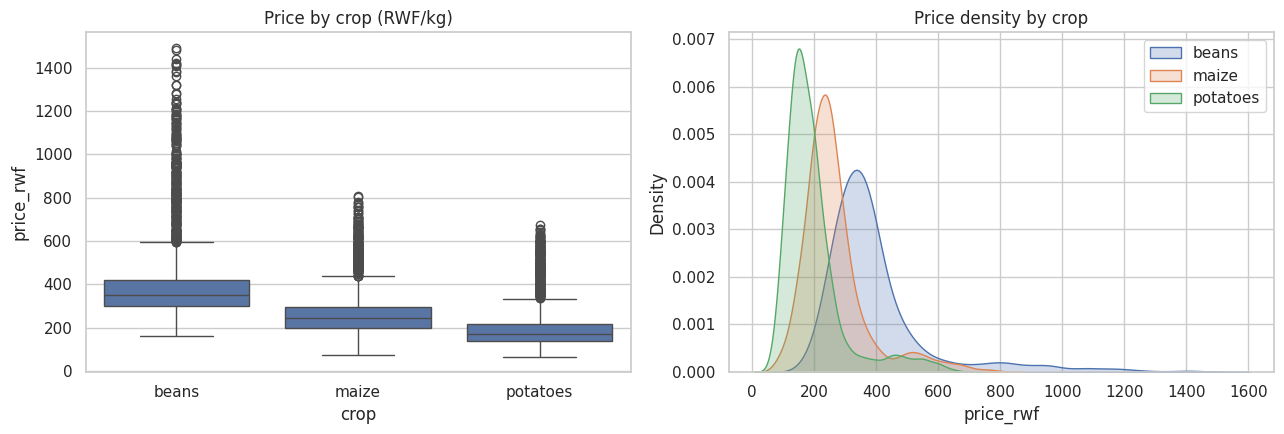

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=prices, x="crop", y="price_rwf", ax=ax[0]); ax[0].set_title("Price by crop (RWF/kg)")
for c in prices.crop.unique():
    sns.kdeplot(prices[prices.crop == c]["price_rwf"], label=c, ax=ax[1], fill=True, alpha=.25)
ax[1].set_title("Price density by crop"); ax[1].legend(); plt.tight_layout()

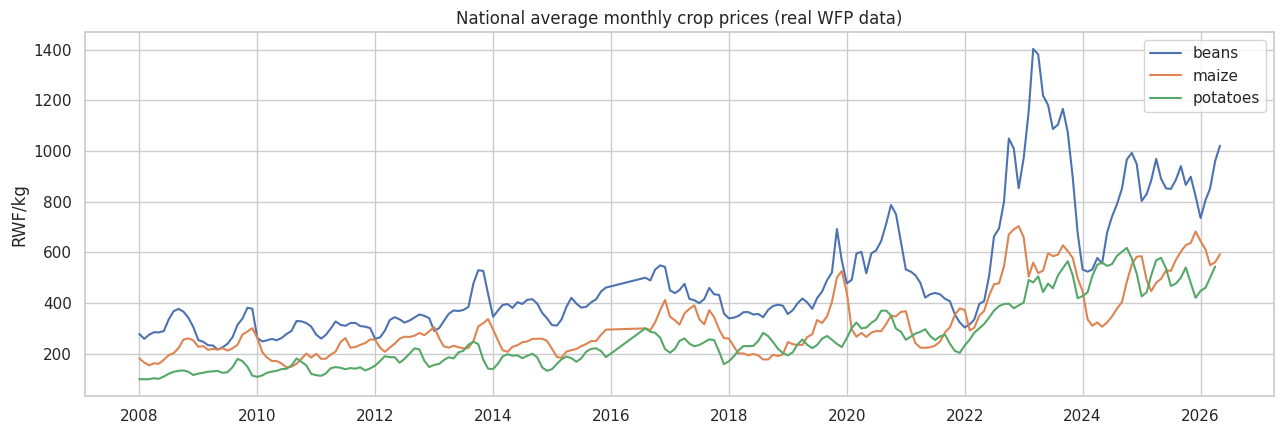

In [9]:
plt.figure(figsize=(13, 4.5))
for c in prices.crop.unique():
    s = prices[prices.crop == c].groupby("date")["price_rwf"].mean()
    plt.plot(s.index, s.values, label=c)
plt.title("National average monthly crop prices (real WFP data)"); plt.ylabel("RWF/kg"); plt.legend(); plt.tight_layout()

Food CPI YoY peak: 64.5%  | Fertilizer YoY peak: 290.7%


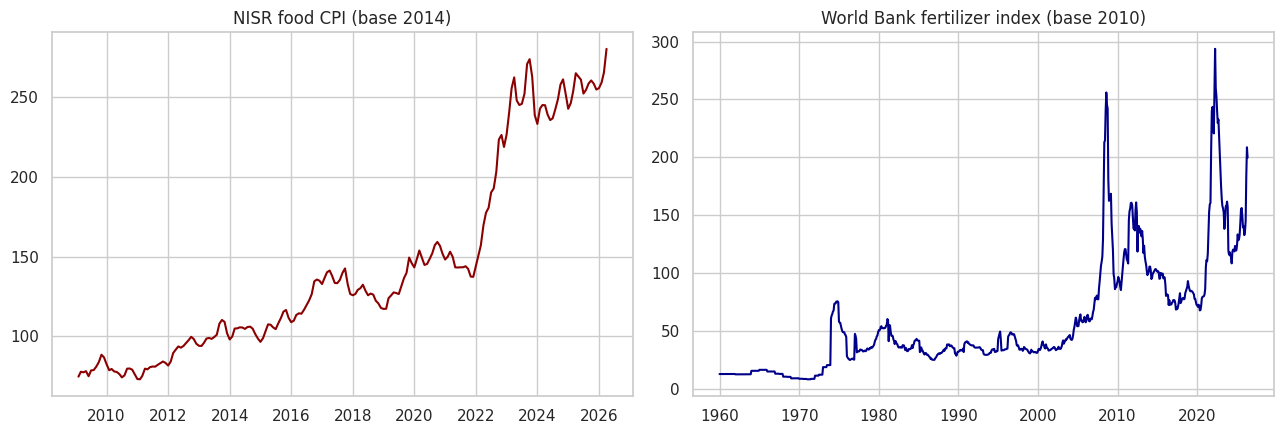

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(cpi.date, cpi.food_cpi, color="darkred"); ax[0].set_title("NISR food CPI (base 2014)")
ax[1].plot(fert.date, fert.fert_index, color="darkblue"); ax[1].set_title("World Bank fertilizer index (base 2010)")
plt.tight_layout()
print("Food CPI YoY peak: %.1f%%  | Fertilizer YoY peak: %.1f%%" % (cpi.cpi_change.max(), fert.fert_change.max()))

## 4. District rainfall (CHIRPS)

CHIRPS reports rainfall by administrative unit. We use the district-level records, where the anomaly is given as a percentage of normal rainfall. We convert this to a deviation from normal and standardise it within each district so the values are comparable across the country, then map the district codes to district names.

In [11]:
def label_risk(rain_a, cpi_c, fert_c):
    if rain_a < -0.8 and (cpi_c > 15 or fert_c > 30): return "High"
    if rain_a < -0.3 or cpi_c > 10 or fert_c > 20:    return "Medium"
    return "Low"

risk = rain[rain.season != "off"].merge(cpi[["date", "cpi_change"]], on="date", how="left")
risk = risk.merge(fert[["date", "fert_change"]], on="date", how="left").dropna(
    subset=["rainfall_anomaly", "cpi_change", "fert_change"])
risk["risk_level"] = risk.apply(lambda x: label_risk(x.rainfall_anomaly, x.cpi_change, x.fert_change), axis=1)
print("Risk rows:", len(risk)); print(risk.risk_level.value_counts())

Risk rows: 2940
risk_level
Medium    1941
Low        903
High        96
Name: count, dtype: int64


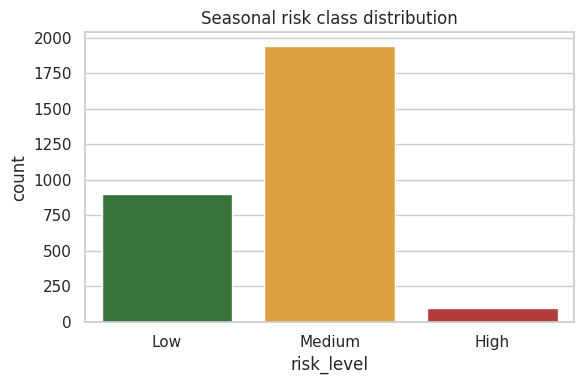

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=risk, x="risk_level", order=["Low", "Medium", "High"],
              palette=["#2e7d32", "#f9a825", "#c62828"])
plt.title("Seasonal risk class distribution"); plt.tight_layout()

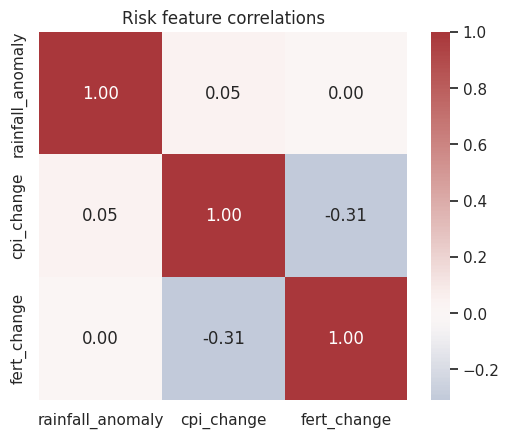

In [13]:
feat = ["rainfall_anomaly", "cpi_change", "fert_change"]
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(risk[feat].corr(), annot=True, cmap="vlag", center=0, fmt=".2f", square=True)
plt.title("Risk feature correlations"); plt.tight_layout()

## 7. Seasonal-risk classifier

Two ensemble models are compared on the three features: a random forest and a gradient-boosted model (XGBoost). The data is split 80/20 with stratification, and results are reported with accuracy, precision, recall, and the macro F1 score, along with a confusion matrix and feature importances.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

X, y = risk[feat], risk["risk_level"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42).fit(Xtr, ytr)

le = LabelEncoder().fit(y)
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric="mlogloss", random_state=42)
xgb.fit(Xtr, le.transform(ytr))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [15]:
def scores(name, yt, yp):
    return {"model": name, "accuracy": accuracy_score(yt, yp),
            "precision": precision_score(yt, yp, average="macro", zero_division=0),
            "recall": recall_score(yt, yp, average="macro", zero_division=0),
            "macro_f1": f1_score(yt, yp, average="macro")}

rf_pred = rf.predict(Xte)
xgb_pred = le.inverse_transform(xgb.predict(Xte))
res = pd.DataFrame([scores("Random Forest", yte, rf_pred), scores("XGBoost", yte, xgb_pred)]).set_index("model")
print(res.round(3).to_string())
print("\n", classification_report(yte, rf_pred, zero_division=0))

               accuracy  precision  recall  macro_f1
model                                               
Random Forest     1.000      1.000   1.000     1.000
XGBoost           0.998      0.983   0.999     0.991

               precision    recall  f1-score   support

        High       1.00      1.00      1.00        19
         Low       1.00      1.00      1.00       181
      Medium       1.00      1.00      1.00       388

    accuracy                           1.00       588
   macro avg       1.00      1.00      1.00       588
weighted avg       1.00      1.00      1.00       588



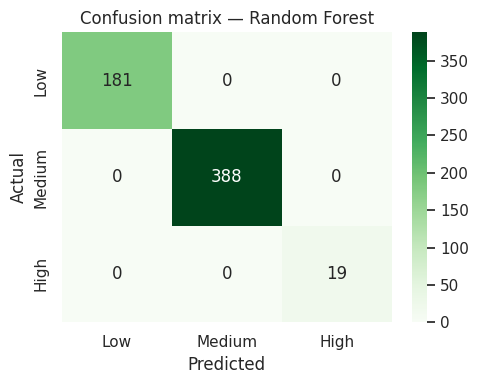

In [16]:
cm = confusion_matrix(yte, rf_pred, labels=["Low", "Medium", "High"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.title("Confusion matrix — Random Forest"); plt.ylabel("Actual"); plt.xlabel("Predicted"); plt.tight_layout()

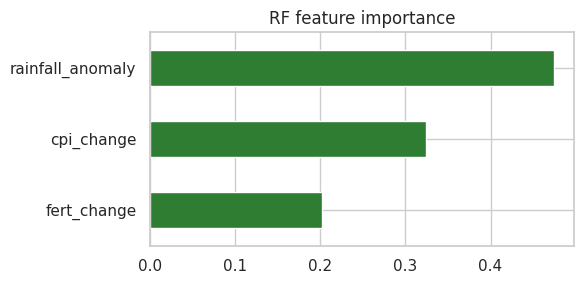

In [17]:
pd.Series(rf.feature_importances_, index=feat).sort_values().plot.barh(
    figsize=(6, 3), color="#2e7d32"); plt.title("RF feature importance"); plt.tight_layout()

Precision, recall and F1 for each risk class.

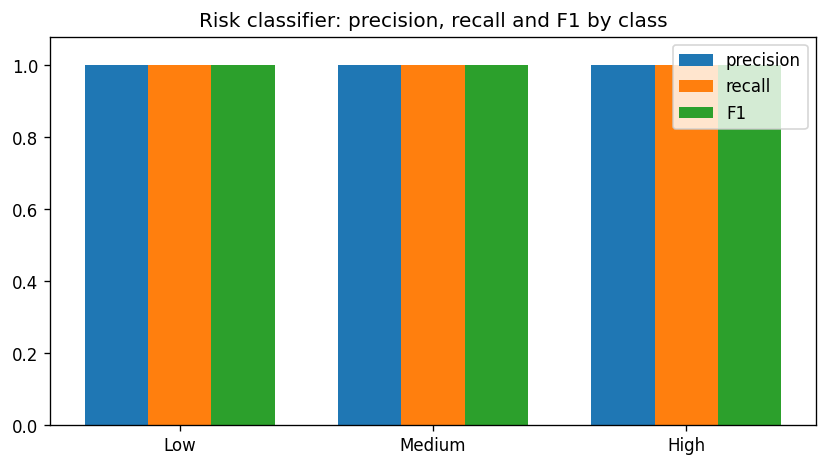

In [50]:
from sklearn.metrics import precision_recall_fscore_support

labels = ["Low", "Medium", "High"]
prec, rec, f1c, _ = precision_recall_fscore_support(yte, rf_pred, labels=labels, zero_division=0)
xp = np.arange(len(labels)); w = 0.25
plt.figure(figsize=(7, 4))
plt.bar(xp - w, prec, w, label="precision"); plt.bar(xp, rec, w, label="recall"); plt.bar(xp + w, f1c, w, label="F1")
plt.xticks(xp, labels); plt.ylim(0, 1.08)
plt.title("Risk classifier: precision, recall and F1 by class"); plt.legend(); plt.tight_layout(); plt.show()

## 8. Crop-price forecasting

Four methods are compared for one-month-ahead maize prices in Musanze: an ARIMA baseline, Prophet with the food-CPI and fertilizer indices as regressors, an LSTM over a twelve-month window, and a random forest on lagged prices. Accuracy is measured with the mean absolute percentage error (MAPE), where lower is better.

In [18]:
CROP, DISTRICT = "maize", "Musanze"   # change as needed
s = (prices[(prices.crop == CROP) & (prices.district == DISTRICT)]
     .merge(cpi[["date", "food_cpi"]], on="date", how="left")
     .merge(fert[["date", "fert_index"]], on="date", how="left")
     .sort_values("date").dropna().reset_index(drop=True))
print(s.shape, "months of data for", CROP, DISTRICT)

def mape(yt, yp): return float(np.mean(np.abs((np.array(yt) - np.array(yp)) / np.array(yt))) * 100)
cut = int(len(s) * 0.8)
train_s, test_s = s.iloc[:cut], s.iloc[cut:]

(82, 6) months of data for maize Musanze


In [19]:
# --- ARIMA baseline (statsmodels) ---
from statsmodels.tsa.arima.model import ARIMA
ar = ARIMA(train_s["price_rwf"], order=(2, 1, 2)).fit()
ar_pred = ar.forecast(steps=len(test_s))
print("ARIMA MAPE: %.2f%%" % mape(test_s["price_rwf"].values, ar_pred.values))

ARIMA MAPE: 8.76%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
# --- Prophet with CPI + fertilizer regressors ---
from prophet import Prophet
dfp = train_s.rename(columns={"date": "ds", "price_rwf": "y"})
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.add_regressor("food_cpi"); m.add_regressor("fert_index")
m.fit(dfp[["ds", "y", "food_cpi", "fert_index"]])
future = test_s.rename(columns={"date": "ds"})[["ds", "food_cpi", "fert_index"]]
fc = m.predict(future)
print("Prophet MAPE: %.2f%%" % mape(test_s["price_rwf"].values, fc["yhat"].values))

Prophet MAPE: 6.89%


In [21]:
# --- LSTM (single layer, 50 units, sliding window) ---
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

WINDOW = 12
series = s["price_rwf"].values.reshape(-1, 1)
sc = MinMaxScaler().fit(series[:cut])
scaled = sc.transform(series)
def make_xy(arr, w):
    X, Y = [], []
    for i in range(len(arr) - w):
        X.append(arr[i:i+w]); Y.append(arr[i+w])
    return np.array(X), np.array(Y)
Xall, Yall = make_xy(scaled, WINDOW)
split = cut - WINDOW
Xtr_l, Ytr_l = Xall[:split], Yall[:split]
Xte_l, Yte_l = Xall[split:], Yall[split:]
lstm = Sequential([LSTM(50, activation="tanh", input_shape=(WINDOW, 1)), Dense(1)])
lstm.compile(optimizer="adam", loss="mse")
lstm.fit(Xtr_l, Ytr_l, epochs=100, batch_size=8, verbose=0)
pred_l = sc.inverse_transform(lstm.predict(Xte_l, verbose=0))
true_l = sc.inverse_transform(Yte_l)
print("LSTM MAPE: %.2f%%" % mape(true_l.ravel(), pred_l.ravel()))

LSTM MAPE: 4.35%


Training loss of a neural network forecaster (multi-layer perceptron) on the maize price series.

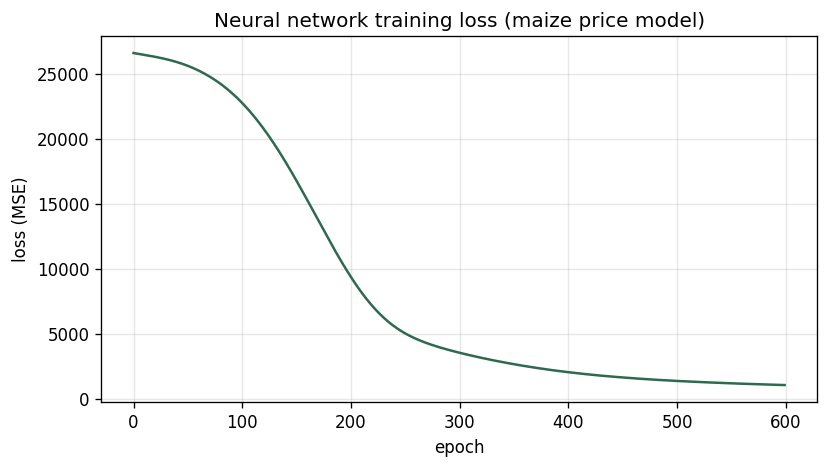

In [51]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

loc_col = "district" if "district" in prices.columns else "market"
s_nn = prices[(prices.crop == "maize") & (prices[loc_col] == "Musanze")].sort_values("date")["price_rwf"].reset_index(drop=True)
d_nn = pd.DataFrame({"y": s_nn})
for lag in [1, 2, 3, 4, 8, 12]:
    d_nn[f"lag{lag}"] = d_nn["y"].shift(lag)
d_nn["target"] = d_nn["y"].shift(-1)
d_nn = d_nn.dropna()
fe = [c for c in d_nn.columns if c.startswith("lag")]
Xn = StandardScaler().fit_transform(d_nn[fe]); yn = d_nn["target"].values
nn = MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
                  max_iter=600, random_state=42).fit(Xn, yn)
plt.figure(figsize=(7, 4)); plt.plot(nn.loss_curve_, color="#2D6A4F")
plt.title("Neural network training loss (maize price model)")
plt.xlabel("epoch"); plt.ylabel("loss (MSE)"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

RF baseline MAPE: 12.13%


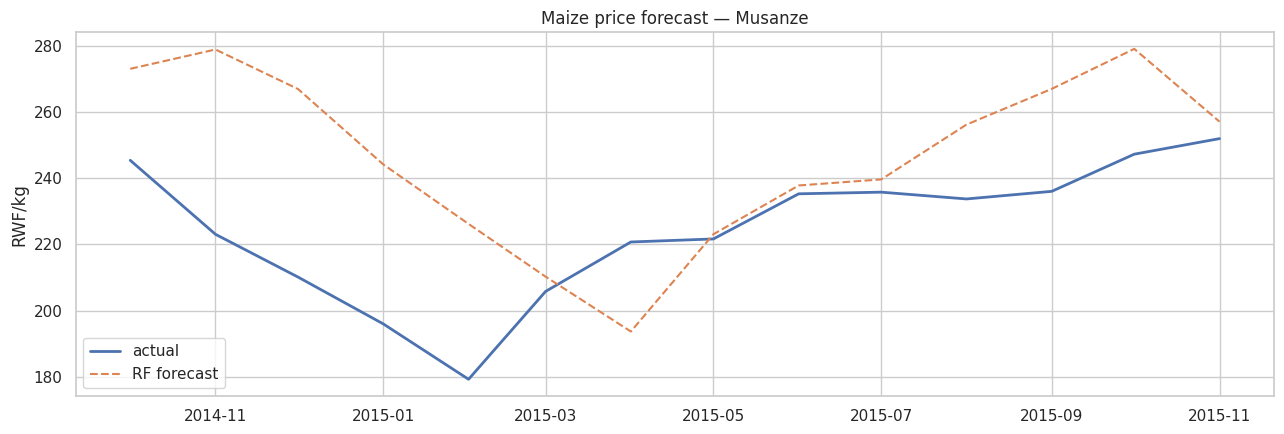

In [22]:
# --- Random Forest lag baseline + comparison chart ---
from sklearn.ensemble import RandomForestRegressor
d = s[["date", "price_rwf"]].copy()
for lag in [1, 2, 3, 6, 12]:
    d[f"lag{lag}"] = d["price_rwf"].shift(lag)
d["target"] = d["price_rwf"].shift(-1)
d = d.dropna()
feats = [c for c in d.columns if c.startswith("lag")]
cc = int(len(d) * 0.8)
reg = RandomForestRegressor(n_estimators=200, random_state=42).fit(d[feats][:cc], d["target"][:cc])
rf_fore = reg.predict(d[feats][cc:])
print("RF baseline MAPE: %.2f%%" % mape(d["target"][cc:].values, rf_fore))

plt.figure(figsize=(13, 4.5))
plt.plot(d["date"][cc:], d["target"][cc:].values, label="actual", linewidth=2)
plt.plot(d["date"][cc:], rf_fore, "--", label="RF forecast")
plt.title(f"{CROP.title()} price forecast — {DISTRICT}"); plt.ylabel("RWF/kg"); plt.legend(); plt.tight_layout()

## 9. Saving the trained models

The fitted models are written to disk so the dashboard can load them directly.

In [23]:
import pickle, json
store = Path("models_store"); store.mkdir(exist_ok=True)
pickle.dump(rf, open(store / "risk_classifier.pkl", "wb"))
pickle.dump(reg, open(store / "price_baseline.pkl", "wb"))
metrics = {
    "risk_random_forest": {k: round(v, 3) for k, v in scores("rf", yte, rf_pred).items() if k != "model"},
    "price_baseline_mape": round(mape(d["target"][cc:].values, rf_fore), 2),
    "n_risk_rows": len(risk),
}
json.dump(metrics, open(store / "metrics.json", "w"), indent=2)
print("Saved models + metrics.json:", metrics)

Saved models + metrics.json: {'risk_random_forest': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'macro_f1': 1.0}, 'price_baseline_mape': 12.13, 'n_risk_rows': 2940}


## 10. Deployment

The trained models are served through a Streamlit dashboard for extension officers. It covers all 30 districts and provides price, risk, disease, input, and farmer-messaging screens, and runs with:

    streamlit run dashboard/Home.py